- Dashboard Tableau: [Link]()
- OpenData Dataset: [Link](https://opendata.jabarprov.go.id/id/dataset/jumlah-desa-berdasarkan-kekuatan-sinyal-telepon-seluler-di-jawa-barat)

## i. Perkenalan

=================================================

**DA Project**

**Nama  :** Adhit Hikmatullah

**Batch :** CODA-RMT-010

=================================================

## ii. Identifikasi Masalah

- **SMART Method**

1. **Specific**: Wilayah mana saja di Jawa Barat yang masih memiliki kualitas sinyal telepon seluler kuat, lemah, dan tidak tersedia sama sekali ? 

2. **Measurable**: Berapa jumlah dan persentase desa di setiap kabupaten/kota di Jawa Barat berdasarkan kategori kekuatan sinyal telepon seluler (baik itu kuat, lemah, dan tidak ada sinyal) ?

3. **Achievable**: Bagaimana data dapat dianalisis melalui pengolahan data dan exploratory data analysis untuk mengidentifikasi pola dan ketimpangan antar wilayah ? 

4. **Relevant**: Wilayah mana saja yang perlu diprioritaskan untuk peningkatan infrastruktur telekomunikasi agar pemerataan akses komunikasi dan layanan digital dapat ditingkatkan secara efektif ?

5. **Time-Bound**: Wilayah mana yang sebaiknya menjadi fokus intervensi peningkatan kualitas sinyal telepon seluler dalam jangka waktu 1–3 tahun ke depan ?

`Problem statement`:

Bagaimana kondisi dan persebaran kualitas sinyal telepon seluler di desa-desa Jawa Barat, dan wilayah mana yang harus diprioritaskan dalam 1–3 tahun ke depan untuk mempercepat pemerataan akses digital ?

- **Objective Analysis**

Tujuan utama adalah memahami kondisi dan persebaran kekuatan sinyal telepon seluler pada desa di Jawa Barat, serta mengidentifikasi wilayah prioritas mana yang membutuhkan peningkatan infrastruktur jaringan untuk mendukung pemerataan akses digital

- **Penjabaran Masalah**
1. Bagaimana distribusi jumlah desa berdasarkan kategori kekuatan sinyal telepon seluler ?
2. Kabupaten/kota mana yang memiliki jumlah desa dengan sinyal lemah atau tidak tersedia paling tinggi ?
3. Seberapa besar kesenjangan kualitas sinyal antar wilayah ?
4. Wilayah mana yang seharusnya menjadi prioritas utama dalam pengembangan infrastruktur jaringan ?

## iii. Exploratory Data Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

- **Read dataset**

In [3]:
df = pd.read_csv('Raw Data.csv')
df

,id,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,kekuatan_sinyal,jumlah_desa,satuan,tahun
0,1,32,JAWA BARAT,3201,KABUPATEN BOGOR,SINYAL KUAT,330,DESA,2020
1,2,32,JAWA BARAT,3201,KABUPATEN BOGOR,SINYAL LEMAH,84,DESA,2020
2,3,32,JAWA BARAT,3201,KABUPATEN BOGOR,TIDAK ADA SINYAL,2,DESA,2020
3,4,32,JAWA BARAT,3202,KABUPATEN SUKABUMI,SINYAL KUAT,267,DESA,2020
4,5,32,JAWA BARAT,3202,KABUPATEN SUKABUMI,SINYAL LEMAH,112,DESA,2020
...,...,...,...,...,...,...,...,...,...
280,281,32,JAWA BARAT,3218,KABUPATEN PANGANDARAN,SINYAL LEMAH,19,DESA,2024
281,282,32,JAWA BARAT,3218,KABUPATEN PANGANDARAN,TIDAK ADA SINYAL,0,DESA,2024
282,283,32,JAWA BARAT,3279,KOTA BANJAR,SINYAL KUAT,15,DESA,2024
283,284,32,JAWA BARAT,3279,KOTA BANJAR,SINYAL LEMAH,1,DESA,2024


- **Menampilkan 5 data awal dan akhir**

In [4]:
df.head()

,id,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,kekuatan_sinyal,jumlah_desa,satuan,tahun
0,1,32,JAWA BARAT,3201,KABUPATEN BOGOR,SINYAL KUAT,330,DESA,2020
1,2,32,JAWA BARAT,3201,KABUPATEN BOGOR,SINYAL LEMAH,84,DESA,2020
2,3,32,JAWA BARAT,3201,KABUPATEN BOGOR,TIDAK ADA SINYAL,2,DESA,2020
3,4,32,JAWA BARAT,3202,KABUPATEN SUKABUMI,SINYAL KUAT,267,DESA,2020
4,5,32,JAWA BARAT,3202,KABUPATEN SUKABUMI,SINYAL LEMAH,112,DESA,2020


In [5]:
df.tail()

,id,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,kekuatan_sinyal,jumlah_desa,satuan,tahun
280,281,32,JAWA BARAT,3218,KABUPATEN PANGANDARAN,SINYAL LEMAH,19,DESA,2024
281,282,32,JAWA BARAT,3218,KABUPATEN PANGANDARAN,TIDAK ADA SINYAL,0,DESA,2024
282,283,32,JAWA BARAT,3279,KOTA BANJAR,SINYAL KUAT,15,DESA,2024
283,284,32,JAWA BARAT,3279,KOTA BANJAR,SINYAL LEMAH,1,DESA,2024
284,285,32,JAWA BARAT,3279,KOTA BANJAR,TIDAK ADA SINYAL,0,DESA,2024


- **Menampilkan info dataframe**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   285 non-null    int64 
 1   kode_provinsi        285 non-null    int64 
 2   nama_provinsi        285 non-null    object
 3   kode_kabupaten_kota  285 non-null    int64 
 4   nama_kabupaten_kota  285 non-null    object
 5   kekuatan_sinyal      285 non-null    object
 6   jumlah_desa          285 non-null    int64 
 7   satuan               285 non-null    object
 8   tahun                285 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 20.2+ KB


- **Menampilkan data deskriptif statistik dari kolom numerikal**

In [7]:
df.describe()

,id,kode_provinsi,kode_kabupaten_kota,jumlah_desa,tahun
count,285.000000,285.0,285.000000,285.000000,285.000000
mean,143.000000,32.0,3213.157895,93.185965,2022.000000
std,82.416625,0.0,16.348741,117.411056,1.416701
min,1.000000,32.0,3201.000000,0.000000,2020.000000
25%,72.000000,32.0,3205.000000,1.000000,2021.000000
50%,143.000000,32.0,3210.000000,28.000000,2022.000000
75%,214.000000,32.0,3215.000000,168.000000,2023.000000
max,285.000000,32.0,3279.000000,403.000000,2024.000000


- **Menampilkan data deskriptif statistik dari kolom object**

In [8]:
df.describe(include="object")

,nama_provinsi,nama_kabupaten_kota,kekuatan_sinyal,satuan
count,285,285,285,285
unique,1,19,3,1
top,JAWA BARAT,KABUPATEN BOGOR,SINYAL KUAT,DESA
freq,285,15,95,285


- **Menampilkan tipe data tiap kolom**

In [9]:
df.dtypes

id                      int64
kode_provinsi           int64
nama_provinsi          object
kode_kabupaten_kota     int64
nama_kabupaten_kota    object
kekuatan_sinyal        object
jumlah_desa             int64
satuan                 object
tahun                   int64
dtype: object

- **Menampilkan jumlah kolom dan baris**

In [10]:
df.shape

(285, 9)

- **Menampilkan jumlah data yang kosong pada tiap kolom**  

In [11]:
df.isnull().sum()

id                     0
kode_provinsi          0
nama_provinsi          0
kode_kabupaten_kota    0
nama_kabupaten_kota    0
kekuatan_sinyal        0
jumlah_desa            0
satuan                 0
tahun                  0
dtype: int64

- **Menampilkan jumlah data unik tiap kolom**

In [12]:
df.nunique()

id                     285
kode_provinsi            1
nama_provinsi            1
kode_kabupaten_kota     19
nama_kabupaten_kota     19
kekuatan_sinyal          3
jumlah_desa            121
satuan                   1
tahun                    5
dtype: int64

In [13]:
df["kekuatan_sinyal"].value_counts()

kekuatan_sinyal
SINYAL KUAT         95
SINYAL LEMAH        95
TIDAK ADA SINYAL    95
Name: count, dtype: int64

- **Menampilkan list kolom**

In [15]:
df.columns

Index(['id', 'kode_provinsi', 'nama_provinsi', 'kode_kabupaten_kota',
       'nama_kabupaten_kota', 'kekuatan_sinyal', 'jumlah_desa', 'satuan',
       'tahun'],
      dtype='object')

## iv. Analisis dan Perhitungan

### Total Desa per Kategori Sinyal

In [ ]:
stat_tahunan = (df.groupby(['tahun', 'kekuatan_sinyal'])['jumlah_desa'].sum().reset_index())

stat_tahunan

,tahun,kekuatan_sinyal,jumlah_desa
0,2020,SINYAL KUAT,4314
1,2020,SINYAL LEMAH,970
2,2020,TIDAK ADA SINYAL,28
3,2021,SINYAL KUAT,4394
4,2021,SINYAL LEMAH,895
5,2021,TIDAK ADA SINYAL,23
6,2022,SINYAL KUAT,4483
7,2022,SINYAL LEMAH,815
8,2022,TIDAK ADA SINYAL,13
9,2023,SINYAL KUAT,4484


### Distribusi Kekuatan Sinyal per Tahun

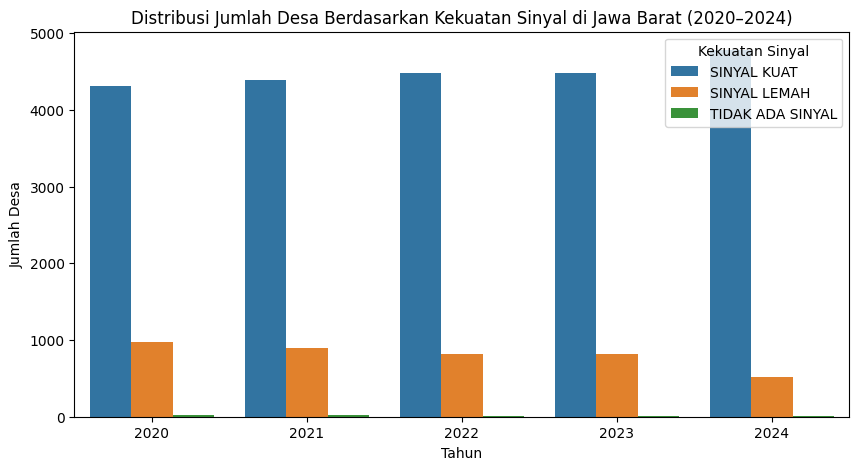

In [ ]:

##PAKE LINE CHART
plt.figure(figsize=(10,5))
sns.barplot(
    data=stat_tahunan,
    x='tahun',
    y='jumlah_desa',
    hue='kekuatan_sinyal'
)

plt.title("Distribusi Jumlah Desa Berdasarkan Kekuatan Sinyal di Jawa Barat (2020–2024)")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Desa")
plt.legend(title="Kekuatan Sinyal")
plt.show()

**Insight**

Dari distribusi bar chart di atas, dapat dilihat bahwa jumlah desa dengan sinyal kuat masih sangat mendominasi tiap tahun-nya dan seiring waktu jumlah desa dengan sinyal kuat juga bertambah. Sebaliknya, jumlah desa dengan sinyal lemah atau tidak ada semakin berkurang tiap tahun-nya. Namun, tentunya masih ada ruang untuk perbaikan bagi desa dengan sinyal yang masih lemah maupun yang tidak ada.

### Kabupaten/Kota dengan Desa Bersinyal Lemah / Tidak Ada (Per Tahun)

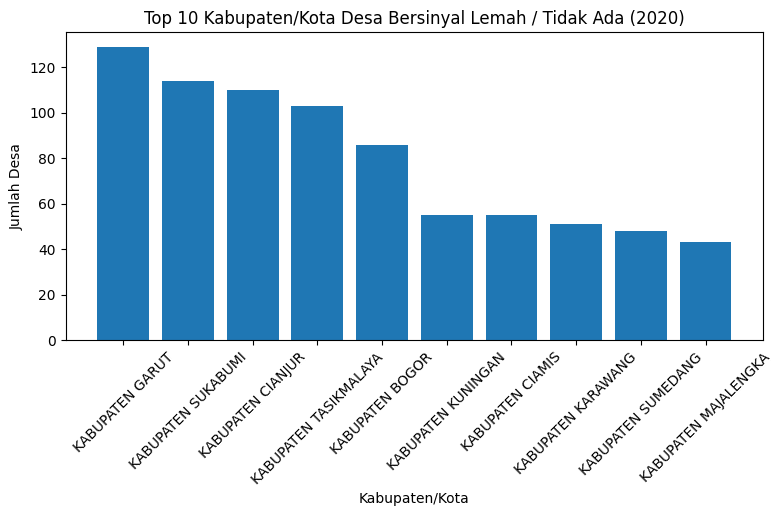

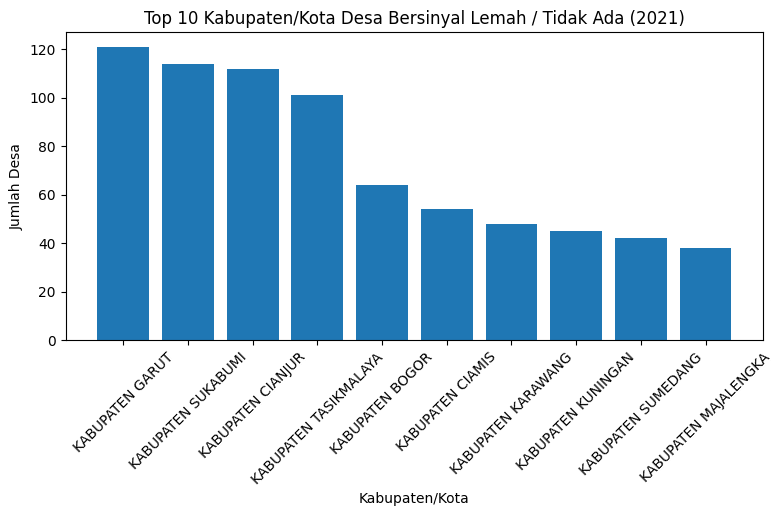

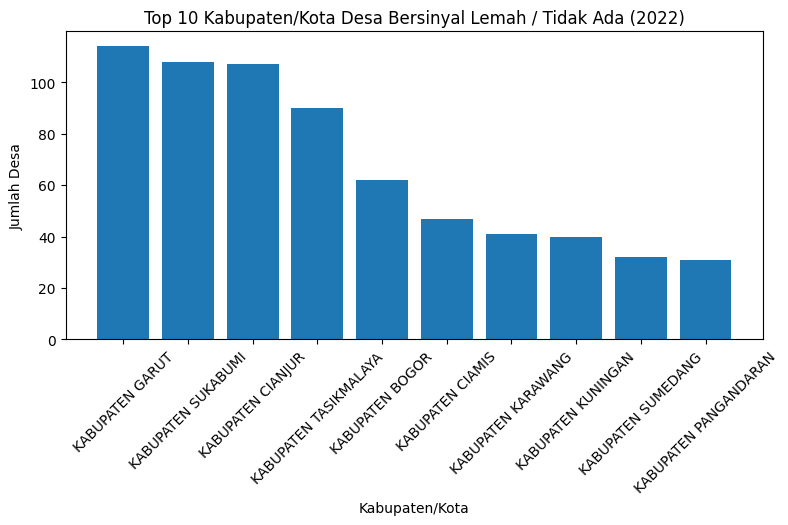

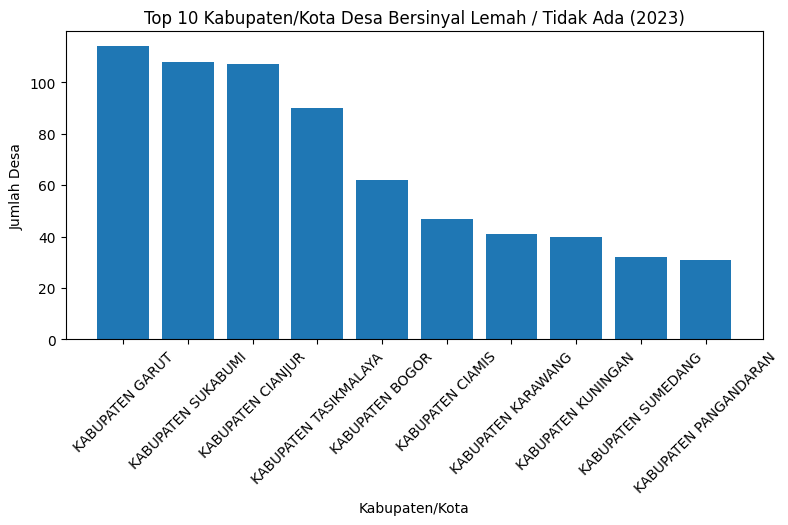

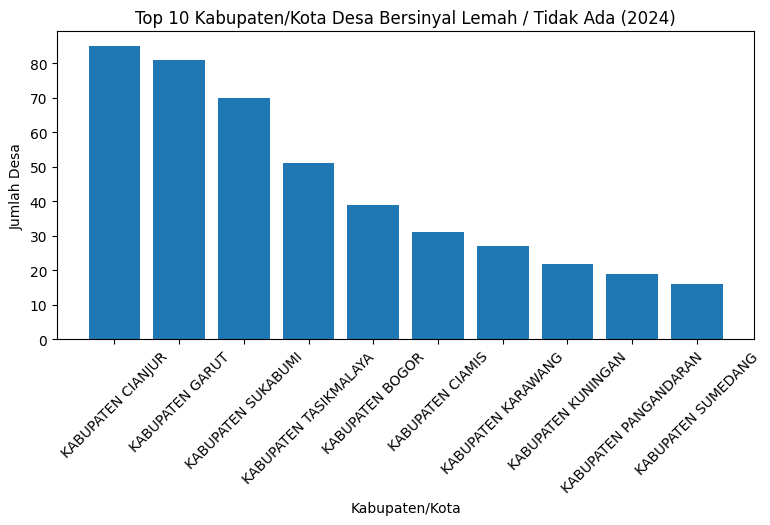

In [ ]:
df['kekuatan_sinyal'] = df['kekuatan_sinyal'].str.lower().str.strip()
df['tahun'] = df['tahun'].astype(int)

for year in sorted(df['tahun'].unique()):
    data_year = df[df['tahun'] == year]

    prioritas = (
        data_year[
            data_year['kekuatan_sinyal'].isin(['sinyal lemah', 'tidak ada sinyal'])
        ]
        .groupby('nama_kabupaten_kota')['jumlah_desa']
        .sum()
        .sort_values(ascending=False)
        .head(10))

    plt.figure(figsize=(9,4))
    plt.bar(prioritas.index, prioritas.values)
    plt.title(f"Top 10 Kabupaten/Kota Desa Bersinyal Lemah / Tidak Ada ({year})")
    plt.xlabel("Kabupaten/Kota")
    plt.ylabel("Jumlah Desa")
    plt.xticks(rotation=45)
    plt.show()

**Insight**

Dari visualisasi di atas, dapat dilihat dari tahun-ke-tahunnya jumlah desa yang mempunyai sinyal lemah dan tidak ada sinyal makin berkurang. Top 5 untuk wilayah yang masih mempunyai sinyal dan tidak ada sinyal diantaranya Kabupaten Cianjur, Kabupaten Garut, Kabupaten Sukabumi, Kabupaten Tasikmalaya, dan Kabupaten Bogor. Salah satu poin yang menarik adalah Kabupaten Garut dan Kabupaten Sukabumi menghasilkan progres yang cukup positif dari 2023 sampai 2024, dimana penurunan desa dengan sinyal rendah dapat ditekan dengan baik. Berbanding terbalik dengan Kabupaten Cianjur yang mana belum ada perubahan dari tahun yang sama.

### Distribusi Kekuatan Sinyal Antar Wilayah

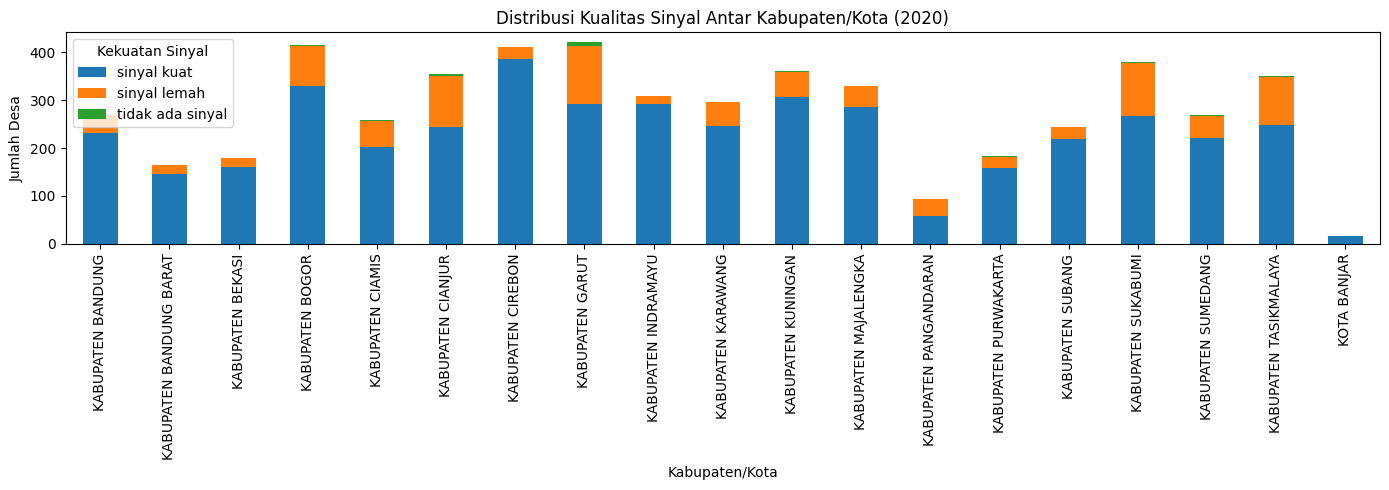

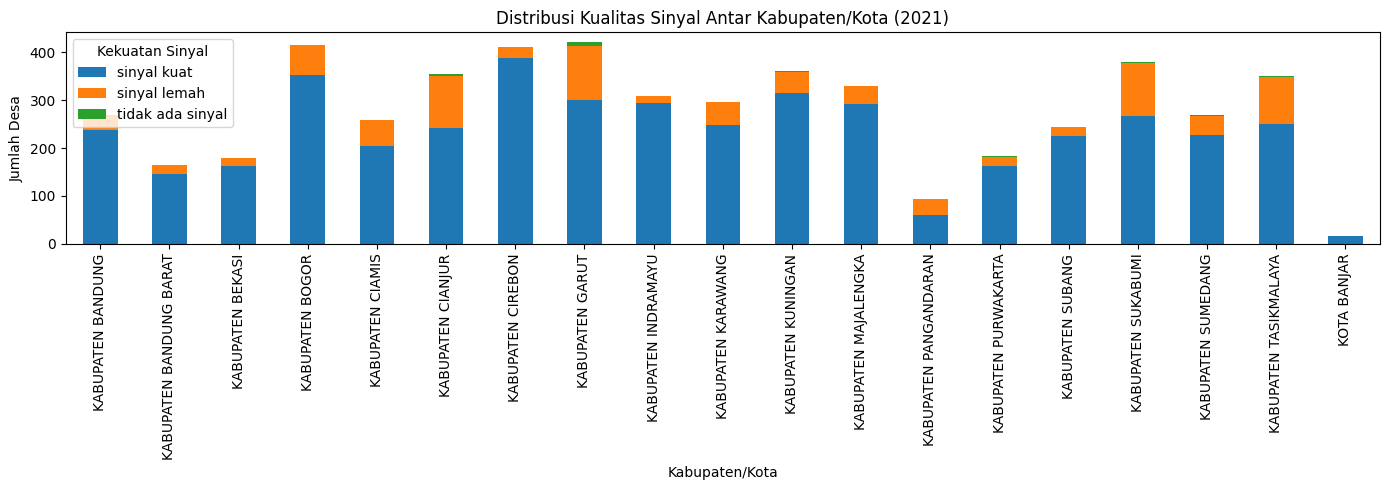

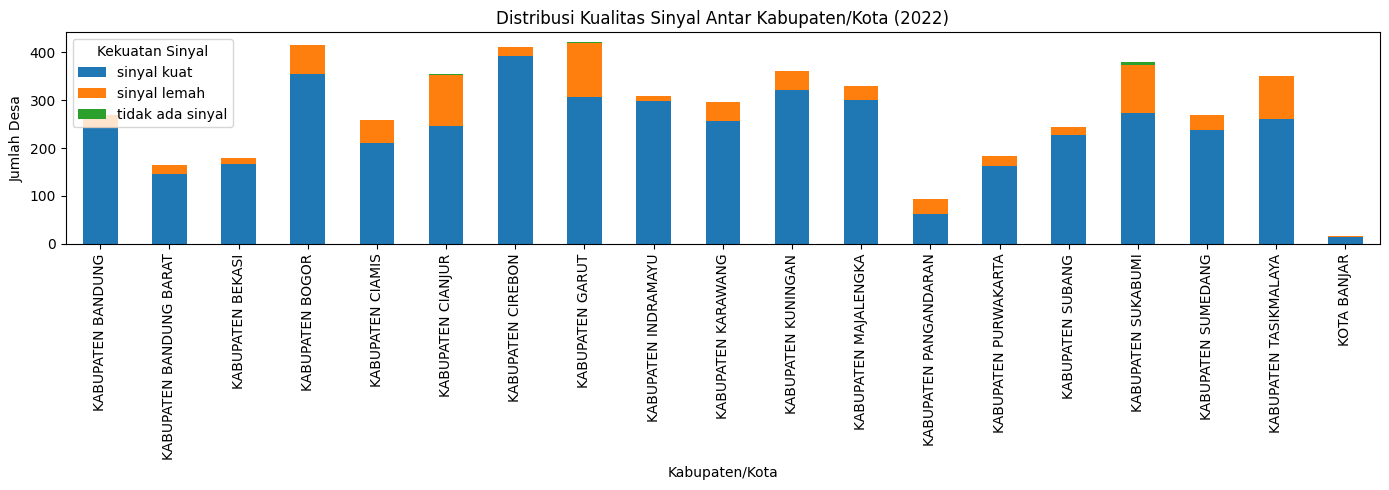

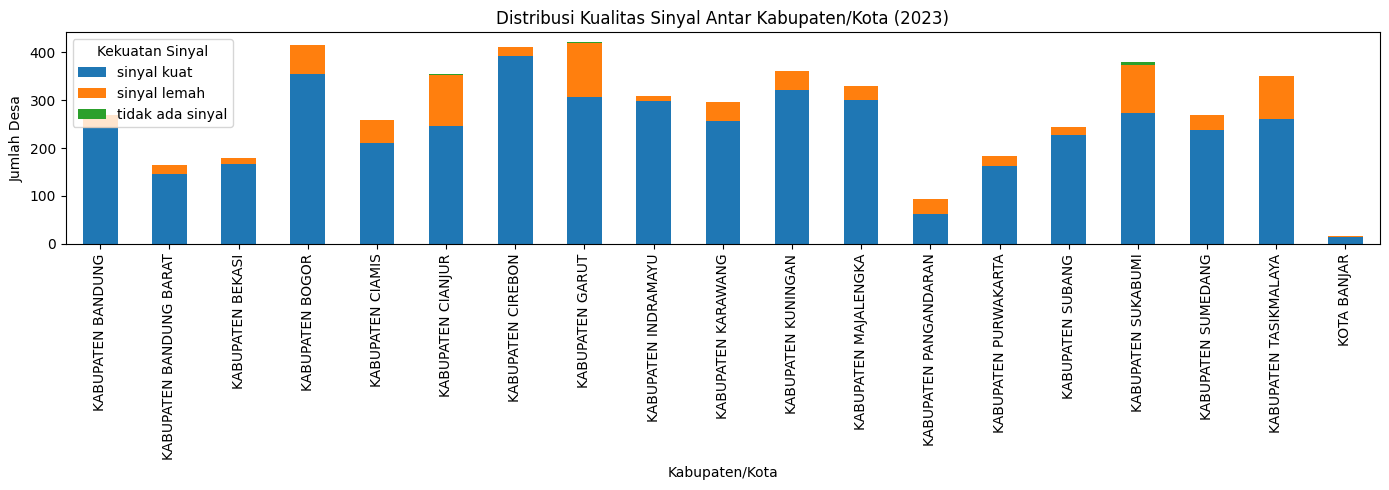

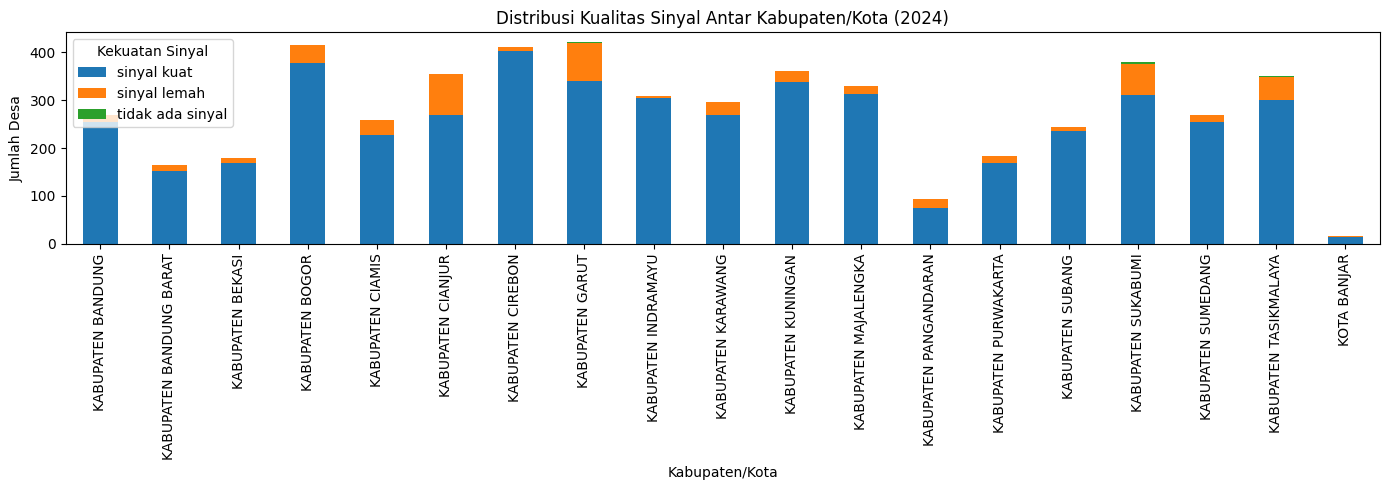

In [61]:
df['kekuatan_sinyal'] = (
    df['kekuatan_sinyal']
    .str.lower()
    .str.strip()
)

df['tahun'] = df['tahun'].astype(int)
df['jumlah_desa'] = pd.to_numeric(df['jumlah_desa'], errors='coerce')

kategori_sinyal = [
    'sinyal kuat',
    'sinyal lemah',
    'tidak ada sinyal'
]

for year in sorted(df['tahun'].unique()):
    data_year = df[df['tahun'] == year]

    pivot = (
        data_year
        .pivot_table(
            index='nama_kabupaten_kota',
            columns='kekuatan_sinyal',
            values='jumlah_desa',
            aggfunc='sum',
            fill_value=0
        )
        .reindex(columns=kategori_sinyal, fill_value=0)
    )

    if pivot.sum().sum() == 0:
        print(f"Tahun {year}: tidak ada data valid")
        continue

    pivot.plot(
        kind='bar',
        stacked=True,
        figsize=(14,5)
    )

    plt.title(f"Distribusi Kualitas Sinyal Antar Kabupaten/Kota ({year})")
    plt.xlabel("Kabupaten/Kota")
    plt.ylabel("Jumlah Desa")
    plt.legend(title="Kekuatan Sinyal")
    plt.tight_layout()
    plt.show()

**Insight**

Dari visualisasi di atas, dapat dilihat distribusi kualitas sinyal antar kabupaten per tahun-nya. Kabupaten/kota dengan desa yang paling banyak mempunyai sinyal kuat adalah Kabupaten Cirebon, Kabupaten Bogor, Kabupaten Kuningan, Kabupaten Garut. Kabupaten/kota dengan desa yang paling banyak mempunyai sinyal lemah/tidak ada adalah Kabupaten Cianjur, Kabupaten Garut, Kabupaten Sukabumi.  

### Wilayah Prioritas Utama

In [54]:
# Normalisasi kategori
df['kekuatan_sinyal'] = (
    df['kekuatan_sinyal']
    .str.lower()
    .str.strip()
)

df['tahun'] = df['tahun'].astype(int)
df['jumlah_desa'] = pd.to_numeric(df['jumlah_desa'], errors='coerce')

# Mapping bobot
bobot = {
    'tidak ada sinyal': 2,
    'sinyal lemah': 1,
    'sinyal kuat': 0
}

df['bobot'] = df['kekuatan_sinyal'].map(bobot)

In [57]:
priority_index = (
    df.groupby(['tahun', 'nama_kabupaten_kota'])
    .apply(lambda x: (x['jumlah_desa'] * x['bobot']).sum())
    .reset_index(name='priority_index')
)

priority_index

C:\Users\adhit\AppData\Local\Temp\ipykernel_38444\611049460.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['jumlah_desa'] * x['bobot']).sum())


,tahun,nama_kabupaten_kota,priority_index
0,2020,KABUPATEN BANDUNG,39
1,2020,KABUPATEN BANDUNG BARAT,19
2,2020,KABUPATEN BEKASI,20
3,2020,KABUPATEN BOGOR,88
4,2020,KABUPATEN CIAMIS,56
...,...,...,...
90,2024,KABUPATEN SUBANG,9
91,2024,KABUPATEN SUKABUMI,76
92,2024,KABUPATEN SUMEDANG,16
93,2024,KABUPATEN TASIKMALAYA,53


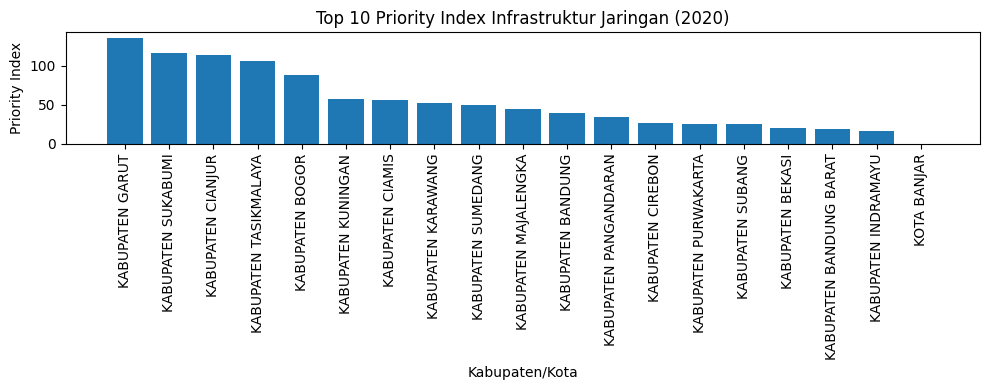

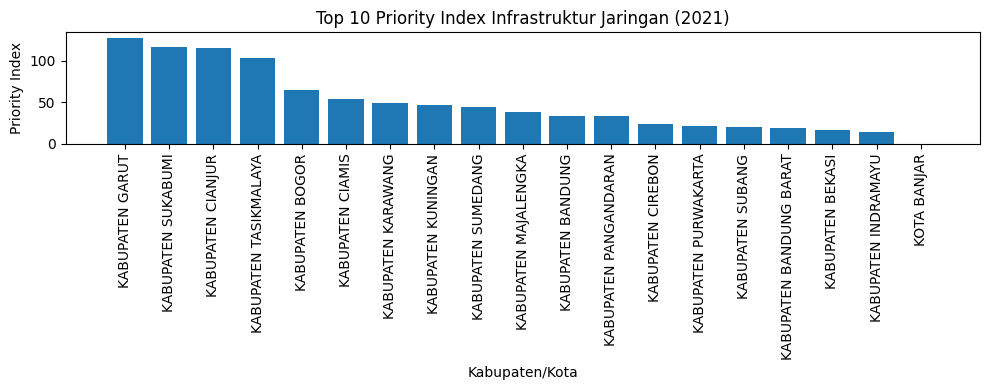

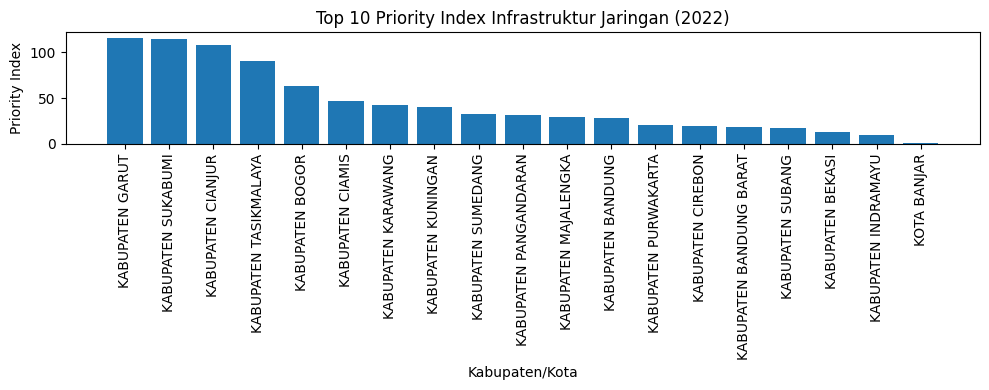

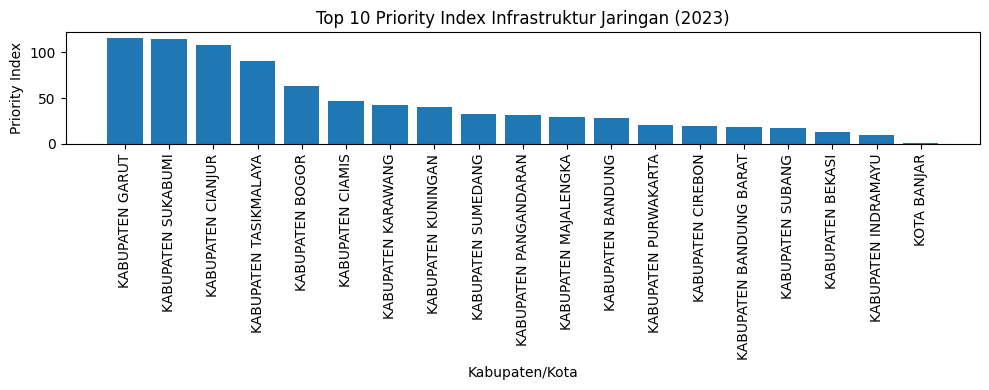

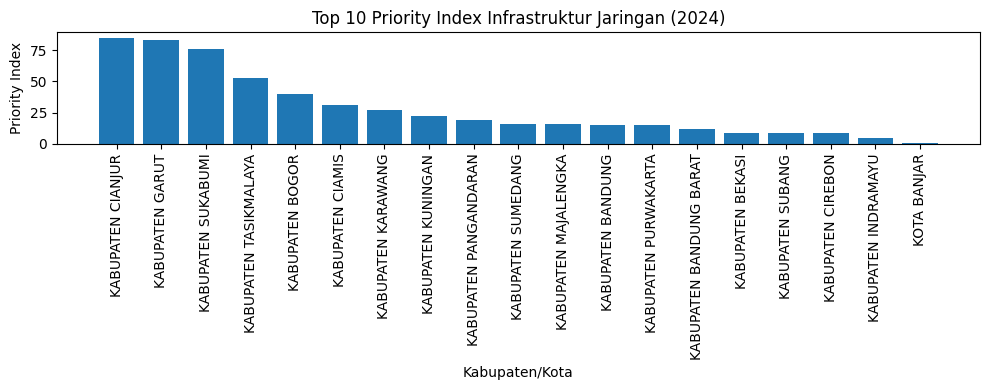

In [60]:
for year in sorted(priority_index['tahun'].unique()):
    data_year = priority_index[priority_index['tahun'] == year]

    top_priority = (
        data_year
        .sort_values('priority_index', ascending=False)
    )

    if top_priority['priority_index'].sum() == 0:
        print(f"Tahun {year}: tidak ada wilayah prioritas (semua sinyal kuat)")
        continue

    plt.figure(figsize=(10,4))
    plt.bar(top_priority['nama_kabupaten_kota'], top_priority['priority_index'])

    plt.title(f"Top 10 Priority Index Infrastruktur Jaringan ({year})")
    plt.xlabel("Kabupaten/Kota")
    plt.ylabel("Priority Index")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

**Insight**

Dari visualisasi di atas, dapat dilihat distribusi kualitas sinyal antar kabupaten per tahun-nya. Wilayah dengan bar chart yang paling tinggi menandakan wilayah tersebut masuk ke prioritas lebih dulu untuk dilakukan peningkatan infrastruktur jaringan.    

## vi. Pengambilan Kesimpulan

1. Prioritas wilayah dengan konsentrasi desa tanpa sinyal

Fokus awal pengembangan infrastruktur pada kabupaten/kota dengan jumlah desa tanpa sinyal tertinggi. Dari visualisasi yang telah dilakukan desa dengan sinyal lemah / tanpa sinyal tertinggi diantaranya adalah Kabupaten Cianjur, Kabupaten Garut, Kabupaten Sukabumi.

2. Segmentasi intervensi berdasarkan tingkat masalah

Desa tanpa sinyal dapat dilakukan pembangunan infrastruktur komunikasi, desa sinyal lemah dapat dilakukan penguatan kapasitas jaringan, desa sinyal kuat dapat dilakukan optimasi dan maintenance untuk infrastruktur-nya.

3. Output yang diharapkan

Dari analisis di atas dihrapkan adanya peningkatan pemerataan akses komunikasi antar wilayah, tidak hanya di Jawa Barat namun juga bisa untuk wilayah Indonesia lainnya. Kemudian dukungan terhadap layanan digital desa bisa ditingkatkan lagi. Lalu diharapkan juga pengambilan keputusan infrastruktur yang lebih tepat sasaran dan berbasis data, tidak hanya daerah kota saja yang mendapat upgrade kualitas sinyal namun daerah sekitar seperti desa bisa mendapat perlakuan yang serupa.